# Comparision between Nelder-Mead, Optimal-Filter and 

In [43]:
# import pandas as pd

# def getOriginalData(path):

#     data = pd.read_csv(path)
#     samples = data['sample'].values
#     amplitudes = data['amplitude'].values

#     pulses = []
#     s4_amplitudes = []
#     for i in range( len(samples)-6 ):
#         pulses.append( samples[ i:i+7 ] )
#         s4_amplitudes.append(amplitudes[i+3])

#     return pulses, s4_amplitudes

# datas = [getOriginalData(r'.\database\original-database\occupancy_0.2.CSV'),
#          getOriginalData(r'.\database\original-database\occupancy_0.5.CSV'),
#          getOriginalData(r'.\database\original-database\occupancy_0.7.CSV'),
#          getOriginalData(r'.\database\original-database\occupancy_0.9.CSV')
#          ]

# samples = pd.DataFrame(datas[0][0], columns = [f"sample({i+1})" for i in range(7)])
# amplitudes = pd.DataFrame(datas[0][1], columns = ['AmplitudeSample(4)'])
# data = pd.concat((samples, amplitudes), axis = 1)
# data.to_csv(r'.\database\data_occ0_2.csv', index = False)

# samples = pd.DataFrame(datas[1][0], columns = [f"sample({i})" for i in range(7)])
# amplitudes = pd.DataFrame(datas[1][1], columns = ['AmplitudeSample(4)'])
# data = pd.concat((samples, amplitudes), axis = 1)
# data.to_csv(r'.\database\data_occ0_5.csv', index = False)

# samples = pd.DataFrame(datas[2][0], columns = [f"sample({i})" for i in range(7)])
# amplitudes = pd.DataFrame(datas[2][1], columns = ['AmplitudeSample(4)'])
# data = pd.concat((samples, amplitudes), axis = 1)
# data.to_csv(r'.\database\data_occ0_7.csv', index = False)

# samples = pd.DataFrame(datas[3][0], columns = [f"sample({i})" for i in range(7)])
# amplitudes = pd.DataFrame(datas[3][1], columns = ['AmplitudeSample(4)'])
# data = pd.concat((samples, amplitudes), axis = 1)
# data.to_csv(r'.\database\data_occ0_9.csv', index = False)

In [44]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
from scipy.optimize import minimize
import seaborn as sns
from datetime import datetime

def trainTestSplit(data, train_prop = 0.5):

    threshold = int(len(data)*train_prop)
    train = data[ :threshold ]
    test = data[ threshold: ]

    return train, test

def getResidual(real_values, estimated_values, show = False):

    residuals = np.array(real_values) - estimated_values

    if show == True:
        fig, ax = plt.subplots(figsize = (10, 10))
        ax.hist(residuals, bins = 50)
        ax.set_xlabel('Residual Value')
        ax.set_ylabel('Frequency')
        plt.show()
    
    return residuals

def optimalFilter2(train, test):

    def of2Weights(train):

        pulse = np.array([0.0000, 0.0172, 0.4524, 1.0000, 0.5633, 0.1493, 0.0424])
        d_pulse = np.array([0.00004019, 0.00333578, 0.03108120, 0.00000000, -0.02434490, -0.00800683, -0.00243344])

        train = np.array(train).T
        covarianceMatrix = np.cov(train)

        b = np.zeros((10,10))
        b[0:7, 0:7] = covarianceMatrix
        b[0:7, 7] = -pulse
        b[0:7, 8] = -d_pulse
        b[0:7, 9] = -1
        b[7, 0:7] = pulse
        b[8, 0:7] = d_pulse
        b[9, 0:7] = 1

        c = np.zeros((10, 1))
        c[7] = 1
        
        aux = np.linalg.solve(b, c)
        weights = aux[0:7].flatten()

        return weights

    weights = of2Weights(train)

    sample4 = []
    for i in range( len(test) ):
        auxSample = test[i] * weights
        auxSample4 = sum(auxSample)
        sample4.append(auxSample4)

    return sample4

def nelderMead(test):

    def objectiveFunction(A):
        signalPattern = np.array([
            A[0]*1.0    + A[1]*0.4524   + A[2]*0.0172   + 0             + 0             + 0             + 0,
            A[0]*0.5633 + A[1]*1        + A[2]*0.4524   + A[3]*0.0172   + 0             + 0             + 0,
            A[0]*0.1493 + A[1]*0.5633   + A[2]*1        + A[3]*0.4524   + A[4]*0.0172   + 0             + 0,
            A[0]*0.0424 + A[1]*0.1493   + A[2]*0.5633   + A[3]*1        + A[4]*0.4524   + A[5]*0.0172   + 0,
            0           + A[1]*0.0424   + A[2]*0.1493   + A[3]*0.5633   + A[4]*1        + A[5]*0.4524   + A[6]*0.0172,
            0           + 0             + A[2]*0.0424   + A[3]*0.1493   + A[4]*0.5633   + A[5]*1        + A[6]*0.4524,
            0           + 0             + 0             + A[3]*0.0424   + A[4]*0.1493   + A[5]*0.5633   + A[6]*1
            ])
        aux_sum = samples - signalPattern
        return (sum(aux_sum**2) / len(samples))**0.5
    
    sample4 = []
    for samples in test:
        sample4.append((minimize(objectiveFunction, samples, method='Nelder-Mead', options={'xatol': 1e-4}).x)[3])

    return sample4
        


In [45]:
data = [pd.read_csv(r'database\data_occ0_2.csv'),
        pd.read_csv(r'database\data_occ0_5.csv'),
        pd.read_csv(r'database\data_occ0_7.csv'),
        pd.read_csv(r'database\data_occ0_9.csv')]

columns = data[0].columns

In [46]:
show = False 
trainSize = 0.8
OF2_residuals = []
NM_residuals = []
NM_time = []

# Dataset with occupancy 0.2
trainData, testData = trainTestSplit(np.array(data[0][columns[0:7]]), trainSize)
_, testAmplitude = trainTestSplit(np.array(data[0][columns[7]]), trainSize)

sample4 = optimalFilter2(trainData, testData)
OF2_residuals.append(getResidual(testAmplitude, sample4, show))
start = datetime.now()
sample4 = nelderMead(testData)
NM_time.append(datetime.now() - start)
NM_residuals.append(getResidual(testAmplitude, sample4, show))

# Dataset with occupancy 0.5
trainData, testData = trainTestSplit(np.array(data[1][columns[0:7]]), trainSize)
_, testAmplitude = trainTestSplit(np.array(data[1][columns[7]]), trainSize)

sample4 = optimalFilter2(trainData, testData)
OF2_residuals.append(getResidual(testAmplitude, sample4, show))
start = datetime.now()
sample4 = nelderMead(testData)
NM_time.append(datetime.now() - start)
NM_residuals.append(getResidual(testAmplitude, sample4, show))

# Dataset with occupancy 0.7
trainData, testData = trainTestSplit(np.array(data[2][columns[0:7]]), trainSize)
_, testAmplitude = trainTestSplit(np.array(data[2][columns[7]]), trainSize)

sample4 = optimalFilter2(trainData, testData)
OF2_residuals.append(getResidual(testAmplitude, sample4, show))
start = datetime.now()
sample4 = nelderMead(testData)
NM_time.append(datetime.now() - start)
NM_residuals.append(getResidual(testAmplitude, sample4, show))

# Dataset with occupancy 0.9
trainData, testData = trainTestSplit(np.array(data[3][columns[0:7]]), trainSize)
_, testAmplitude = trainTestSplit(np.array(data[3][columns[7]]), trainSize)

sample4 = optimalFilter2(trainData, testData)
OF2_residuals.append(getResidual(testAmplitude, sample4, show))
start = datetime.now()
sample4 = nelderMead(testData)
NM_time.append(datetime.now() - start)
NM_residuals.append(getResidual(testAmplitude, sample4, show))

In [47]:
# OF2_results = pd.DataFrame(np.array(OF2_residuals).T, columns = ["occ0_2", "occ0_5", "occ0_7", "occ0_9"])
# OF2_results.to_csv(r'.\results\of2_results.csv', index = False)

# NM_results = pd.DataFrame(np.array(NM_residuals).T, columns = ["occ0_2", "occ0_5", "occ0_7", "occ0_9"])
# NM_results.to_csv(r'.\results\nm_results.csv', index = False)

In [51]:
print(f"Nelder-Mead for 0.2 occupancy: {NM_time[0]}")
print(f"Nelder-Mead for 0.5 occupancy: {NM_time[1]}")
print(f"Nelder-Mead for 0.7 occupancy: {NM_time[2]}")
print(f"Nelder-Mead for 0.9 occupancy: {NM_time[3]}")

Nelder-Mead for 0.2 occupancy: 0:09:51.935672
Nelder-Mead for 0.5 occupancy: 0:09:12.478775
Nelder-Mead for 0.7 occupancy: 0:09:08.563077
Nelder-Mead for 0.9 occupancy: 0:08:45.184902


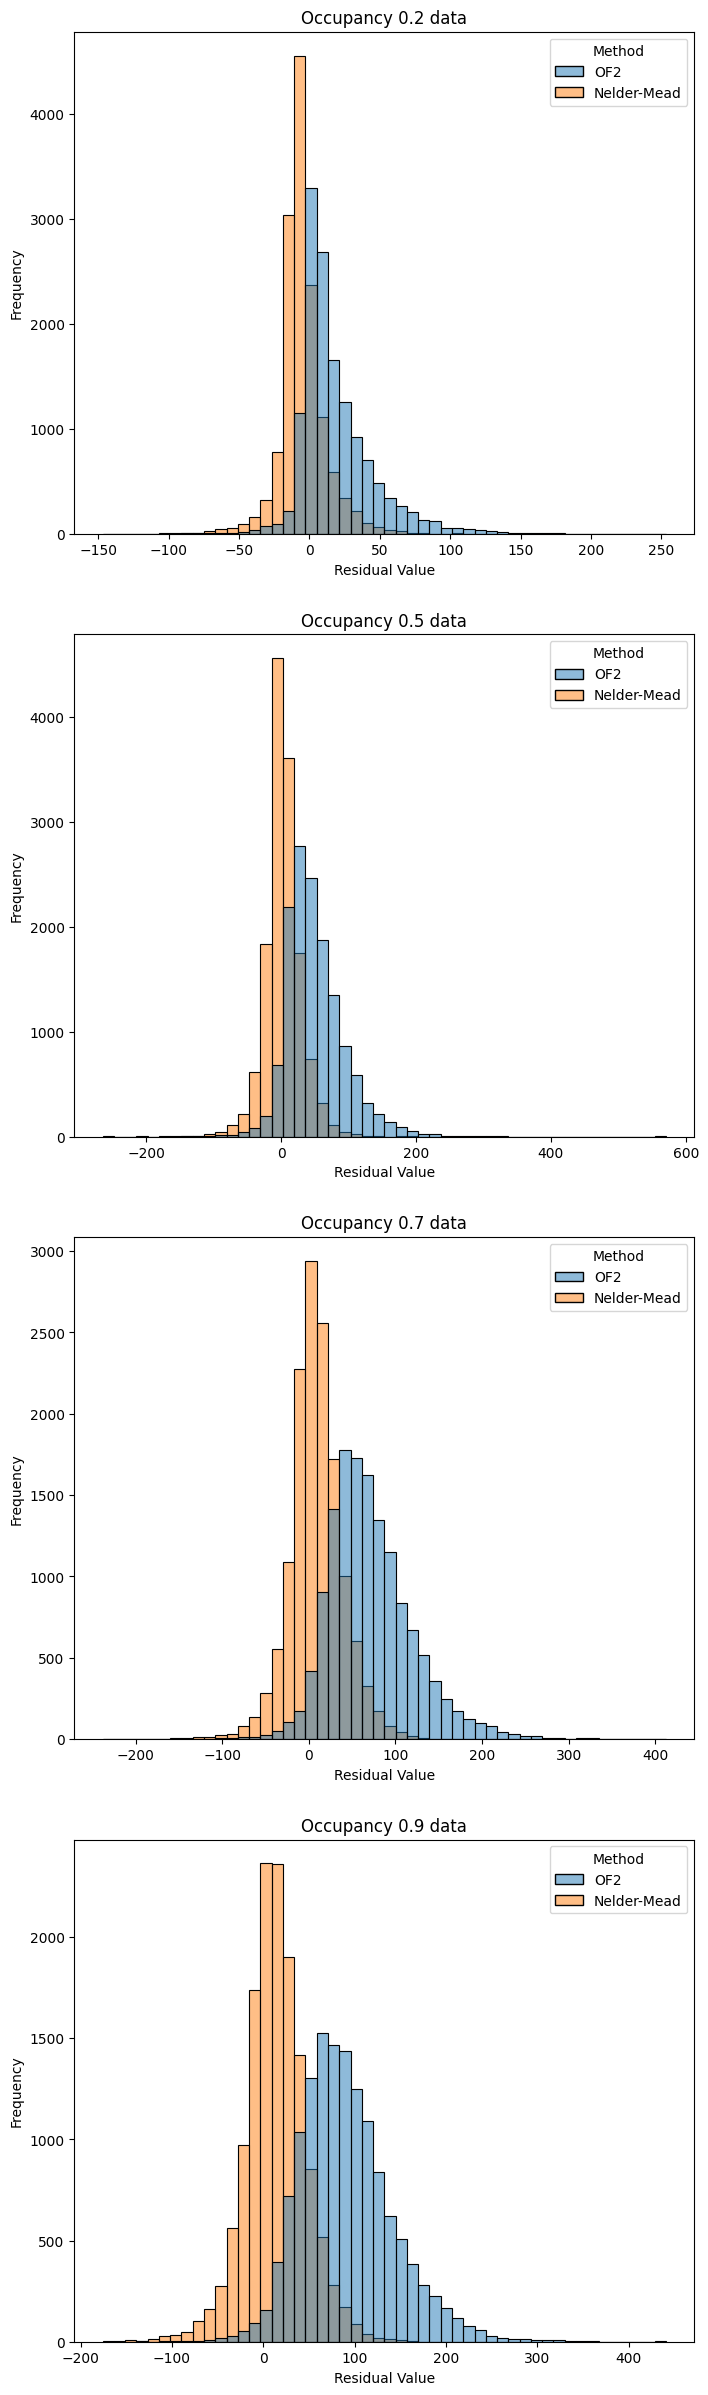

In [48]:
OF2_results = pd.read_csv(r'.\results\of2_results.csv')
NM_results = pd.read_csv(r'.\results\nm_results.csv')

fig, ax = plt.subplots(nrows = 4, ncols = 1, figsize = (8, 30))

results0_2 = pd.concat([pd.DataFrame({"Residual Value": np.array(OF2_results["occ0_2"]), "Method": "OF2"}),
                       pd.DataFrame({"Residual Value": np.array(NM_results["occ0_2"]), "Method": "Nelder-Mead"})])
sns.histplot(data = results0_2, hue = "Method", x = "Residual Value", bins = 50, ax = ax[0])
ax[0].set_ylabel("Frequency")
ax[0].set_title("Occupancy 0.2 data")

results0_5 = pd.concat([pd.DataFrame({"Residual Value": np.array(OF2_results["occ0_5"]), "Method": "OF2"}),
                       pd.DataFrame({"Residual Value": np.array(NM_results["occ0_5"]), "Method": "Nelder-Mead"})])
sns.histplot(data = results0_5, hue = "Method", x = "Residual Value", bins = 50, ax = ax[1])
ax[1].set_ylabel("Frequency")
ax[1].set_title("Occupancy 0.5 data")

results0_7 = pd.concat([pd.DataFrame({"Residual Value": np.array(OF2_results["occ0_7"]), "Method": "OF2"}),
                       pd.DataFrame({"Residual Value": np.array(NM_results["occ0_7"]), "Method": "Nelder-Mead"})])
sns.histplot(data = results0_7, hue = "Method", x = "Residual Value", bins = 50, ax = ax[2])
ax[2].set_ylabel("Frequency")
ax[2].set_title("Occupancy 0.7 data")

results0_9 = pd.concat([pd.DataFrame({"Residual Value": np.array(OF2_results["occ0_9"]), "Method": "OF2"}),
                       pd.DataFrame({"Residual Value": np.array(NM_results["occ0_9"]), "Method": "Nelder-Mead"})])
sns.histplot(data = results0_9, hue = "Method", x = "Residual Value", bins = 50, ax = ax[3])
ax[3].set_ylabel("Frequency")
ax[3].set_title("Occupancy 0.9 data")

plt.show()